# A tour of `graph_coloring`

This notebook walks through the library: the cost function, simulated annealing, bounds on the
chromatic number, and the four applications. Every cell runs in a few seconds.

In [1]:
import matplotlib.pyplot as plt
import networkx as nx

import graph_coloring as gc
from graph_coloring import benchmarks
from graph_coloring.apps import frequency, maps, sudoku, timetabling

%matplotlib inline

## 1. The cost function

$H(x)$ counts edges whose endpoints share a color. A coloring is proper iff $H(x)=0$.

In [2]:
G = nx.erdos_renyi_graph(100, 0.2, seed=1)
x = gc.random_coloring(G, k=7, seed=0)
print("H(random 7-coloring) =", gc.conflicts(G, x))
d = gc.dsatur(G)
print("H(DSATUR coloring)   =", gc.conflicts(G, d), "using", gc.num_colors(d), "colors")

H(random 7-coloring) = 135
H(DSATUR coloring)   = 0 using 8 colors


## 2. Simulated annealing

Moves recolor one node; $\Delta H$ is computed in $O(\deg v)$. By default moves are drawn from the
nodes currently in conflict and the temperature follows a geometric schedule.

AnnealingResult(cost=0, k=7, iterations=186775, solved_at=186775, record_every=1)
proper: True


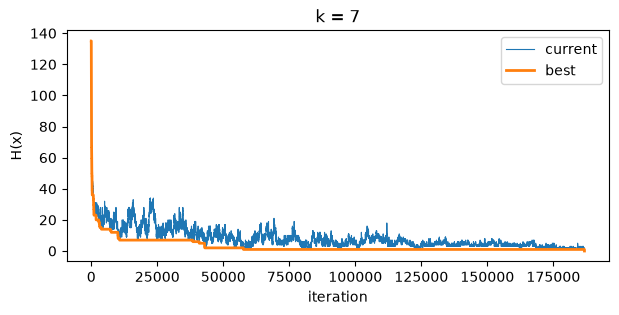

In [3]:
res = gc.simulated_annealing(G, k=7, n_iter=500_000, seed=0)
print(res)
print("proper:", gc.is_proper(G, res.coloring))

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(res.cost_history, lw=0.8, label="current")
ax.plot(res.best_history, lw=2, label="best")
ax.set(xlabel="iteration", ylabel="H(x)", title="k = 7")
ax.legend();

### Cooling schedules

The schedule matters a lot. Too hot and the chain never settles; too cold and it freezes in a local
minimum. Here are several schedules on the same graph with the same budget.

In [4]:
n = 200_000
schedules = {
    "constant T=0.4": gc.Constant(0.4),
    "geometric 0.6 -> 0.1": gc.geometric_for(n, 0.6, 0.1),
    "geometric 2.0 -> 0.02": gc.geometric_for(n, 2.0, 0.02),
    "linear 1.0 -> 0": gc.Linear(1.0, n),
    "logarithmic c=1": gc.Logarithmic(1.0),
    "zero temperature (greedy descent)": gc.Constant(1e-9),
}
for name, sched in schedules.items():
    runs = [gc.simulated_annealing(G, 7, n, sched, seed=s) for s in range(5)]
    solved = sum(r.solved for r in runs)
    print(f"{name:36s} solved {solved}/5, best H = {min(r.cost for r in runs)}")

constant T=0.4                       solved 5/5, best H = 0


geometric 0.6 -> 0.1                 solved 1/5, best H = 0


geometric 2.0 -> 0.02                solved 1/5, best H = 0


linear 1.0 -> 0                      solved 2/5, best H = 0


logarithmic c=1                      solved 0/5, best H = 4


zero temperature (greedy descent)    solved 0/5, best H = 4


There is no universally best schedule. The right temperature scales with the typical size of
$\Delta H$, which grows with the degree: on this graph (mean degree ≈ 20) a constant $T = 0.4$ works
best, but on the much denser timetabling graph (mean degree ≈ 54) the same temperature fails and
the chain needs to start hotter. The default, geometric from 0.6 to 0.1, is a compromise that works
across all the graph families in this repository, and `estimate_chromatic_number` adds restarts
on top. The zero-temperature run shows why annealing exists at all: pure descent gets stuck.

## 3. The chromatic number

`estimate_chromatic_number` squeezes $\chi(G)$ between the clique number and the best $k$ that
annealing can color.

In [5]:
s = gc.estimate_chromatic_number(G, seed=0)
print(f"{s.lower} <= chi(G) <= {s.upper}")
print(
    "Delta + 1 =",
    gc.max_degree_bound(G),
    "| Brooks =",
    gc.brooks_bound(G),
    "| degeneracy + 1 =",
    gc.degeneracy_bound(G),
)

5 <= chi(G) <= 7
Delta + 1 = 30 | Brooks = 29 | degeneracy + 1 = 15


In [6]:
for name in benchmarks.KNOWN:
    H, chi = benchmarks.load(name)
    s = gc.estimate_chromatic_number(H, n_iter=300_000, seed=0)
    print(
        f"{name:10s} omega={s.lower:2d}  DSATUR={gc.num_colors(gc.dsatur(H)):2d}  "
        f"annealing={s.upper:2d}  known chi={chi:2d}"
    )

myciel3    omega= 2  DSATUR= 4  annealing= 4  known chi= 4


myciel4    omega= 2  DSATUR= 5  annealing= 5  known chi= 5


myciel5    omega= 2  DSATUR= 6  annealing= 6  known chi= 6


myciel6    omega= 2  DSATUR= 7  annealing= 7  known chi= 7
queen5_5   omega= 5  DSATUR= 5  annealing= 5  known chi= 5


queen6_6   omega= 6  DSATUR= 9  annealing= 7  known chi= 7


queen7_7   omega= 7  DSATUR=11  annealing= 7  known chi= 7


queen8_8   omega= 8  DSATUR=12  annealing= 9  known chi= 9


queen8_12  omega=12  DSATUR=14  annealing=12  known chi=12


## 4. Sudoku

The Sudoku graph has 81 nodes and 810 edges; clues are fixed colors.

In [7]:
res = sudoku.solve(sudoku.PUZZLES["hard"], seed=0)
print("solved:", res.solved, f"({res.iterations:,} moves, {res.restarts} restarts)")
print(sudoku.to_string(res.grid))

solved: True (3,259,359 moves, 4 restarts)
 8 1 2 | 7 5 3 | 6 4 9
 9 4 3 | 6 8 2 | 1 7 5
 6 7 5 | 4 9 1 | 2 8 3
-------+-------+-------
 1 5 4 | 2 3 7 | 8 9 6
 3 6 9 | 8 4 5 | 7 2 1
 2 8 7 | 1 6 9 | 5 3 4
-------+-------+-------
 5 2 1 | 9 7 4 | 3 6 8
 4 3 8 | 5 2 6 | 9 1 7
 7 9 6 | 3 1 8 | 4 5 2


In [8]:
# The generic one-node-recolor neighbourhood struggles on the hardest puzzles:
res = sudoku.solve(sudoku.PUZZLES["hard"], method="recolor", n_iter=300_000, restarts=3, seed=0)
print("recolor neighbourhood solved:", res.solved, "| best H =", res.cost)

recolor neighbourhood solved: False | best H = 2


## 5. Maps

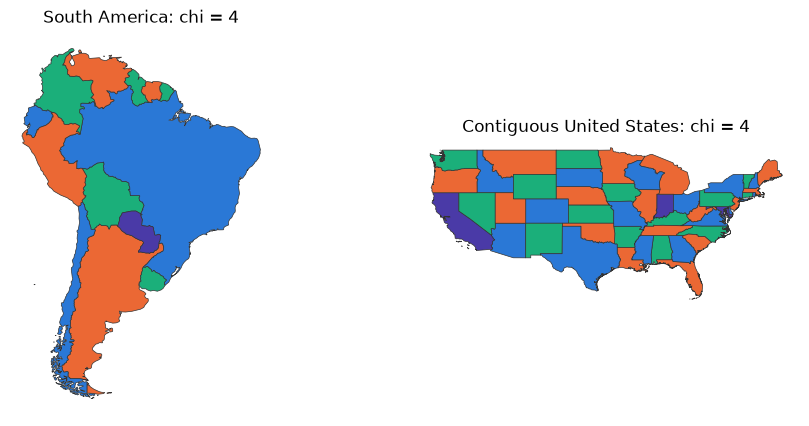

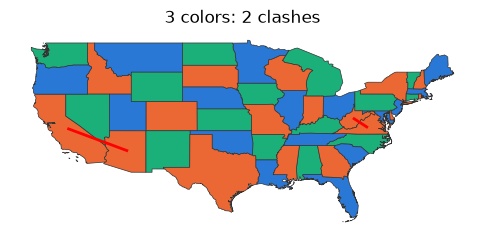

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, name in zip(axes, ["south_america", "us_states"], strict=True):
    m = maps.load_map(name)
    s = gc.estimate_chromatic_number(m.graph, seed=0)
    maps.plot_map(m, s.coloring, ax=ax, title=f"{m.title}: chi = {s.upper}")

# with only 3 colors some borders must clash (red lines)
m = maps.load_map("us_states")
best3 = gc.simulated_annealing(m.graph, 3, 200_000, seed=0)
maps.plot_map(m, best3.coloring, title=f"3 colors: {best3.cost} clashes");

## 6. Frequency assignment

channels: 6 (clique bound 6, greedy 7)


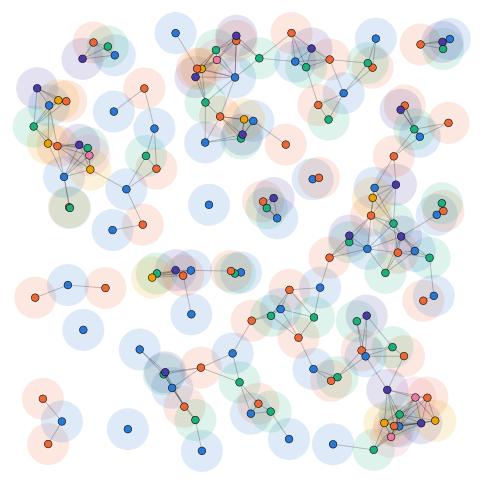

In [10]:
T = frequency.transmitters(150, 0.1, seed=0)
s = gc.estimate_chromatic_number(T, seed=0)
print(f"channels: {s.upper} (clique bound {s.lower}, greedy {gc.num_colors(gc.greedy(T))})")
frequency.plot_channels(T, s.coloring, radius=0.1);

## 7. Timetabling

In [11]:
faculty = timetabling.random_faculty(seed=0)
C = timetabling.conflict_graph(faculty)
s = gc.estimate_chromatic_number(C, seed=0)
print(f"{len(faculty.courses)} courses, {faculty.n_students} students")
print(f"{s.upper} time slots (at least {s.lower} needed)")
print("clashes:", timetabling.clashes(C, s.coloring))
for slot, courses in list(timetabling.timetable(s.coloring).items())[:6]:
    print(slot, courses)

100 courses, 800 students
27 time slots (at least 26 needed)
clashes: 0
Mon-1 ['AST101', 'AST203', 'MAT302', 'MAT403']
Mon-2 ['AST404', 'EST205', 'INF103', 'INF204']
Mon-3 ['FIS405', 'INF105', 'MAT203']
Mon-4 ['FIS203', 'INF203', 'MAT404']
Mon-5 ['AST105', 'AST205', 'AST302', 'MAT402']
Mon-6 ['AST104', 'AST403', 'EST303']
